# Preliminary Results

Questions:
1. Do macroeconomic and news signals move 1–3 months before WARN layoff spikes?
2. Do news features improve prediction beyond macro variables alone?
3. Can layoffs be grouped into low / medium / high risk months?

In [4]:
# pip install statsmodels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm


In [5]:
master = pd.read_csv("../data/processed/master_monthly.csv")
master["month"] = pd.to_datetime(master["month"])

os.makedirs("../data/processed/figures", exist_ok=True)

master.head()

,month,warn_layoffs,ca_unemployment_rate,fed_funds_rate,indeed_job_postings_index,news_volume,news_tone,warn_layoffs_log1p,news_volume_log1p,ca_unemployment_rate_lag1,...,news_volume_log1p_lag3,news_tone_lag1,news_tone_lag2,news_tone_lag3,warn_layoffs_z,ca_unemployment_rate_z,fed_funds_rate_z,indeed_job_postings_index_z,news_volume_z,news_tone_z
0,2020-07-01,32814,NaN,NaN,NaN,64201,-2.080829,10.398641,11.069790,NaN,...,NaN,NaN,NaN,NaN,5.268537,NaN,NaN,NaN,4.414589,-1.912911
1,2020-08-01,15544,NaN,NaN,NaN,47418,-2.014797,9.651494,10.766778,NaN,...,NaN,-2.080829,NaN,NaN,1.767228,NaN,NaN,NaN,2.807788,-1.633807
2,2020-09-01,14535,NaN,NaN,NaN,41715,-1.978027,9.584384,10.638640,NaN,...,NaN,-2.014797,-2.080829,NaN,1.562664,NaN,NaN,NaN,2.261784,-1.478387
3,2020-10-01,10477,NaN,NaN,NaN,27663,-1.937167,9.257033,10.227887,NaN,...,11.069790,-1.978027,-2.014797,-2.080829,0.739948,NaN,NaN,NaN,0.916448,-1.305681
4,2020-11-01,9323,NaN,NaN,NaN,19858,-1.985260,9.140347,9.896413,NaN,...,10.766778,-1.937167,-1.978027,-2.014797,0.505987,NaN,NaN,NaN,0.169199,-1.508961


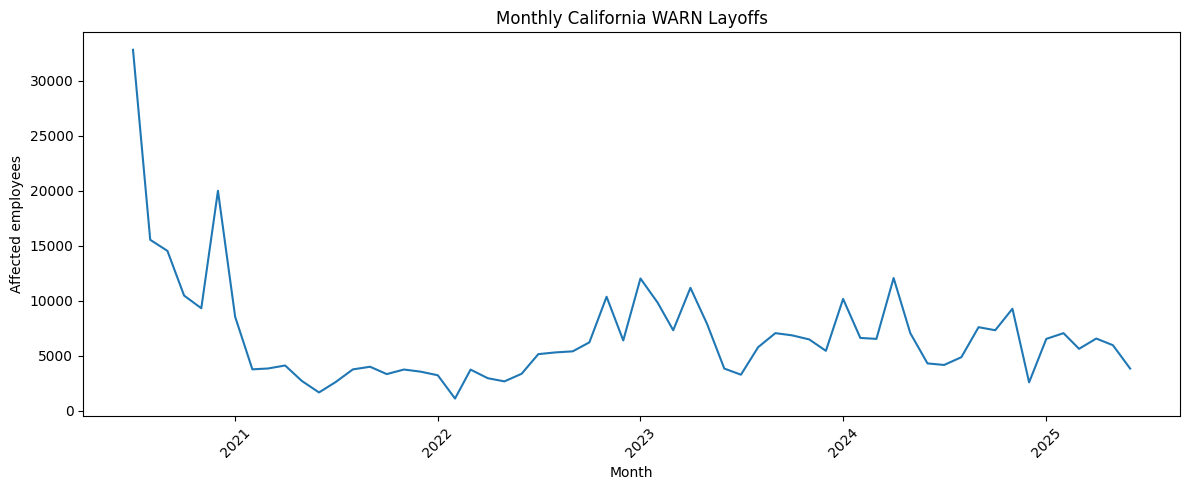

In [6]:
# Main target over time
plt.figure(figsize=(12, 5))
plt.plot(master["month"], master["warn_layoffs"])
plt.title("Monthly California WARN Layoffs")
plt.xlabel("Month")
plt.ylabel("Affected employees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/figures/01_warn_layoffs_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

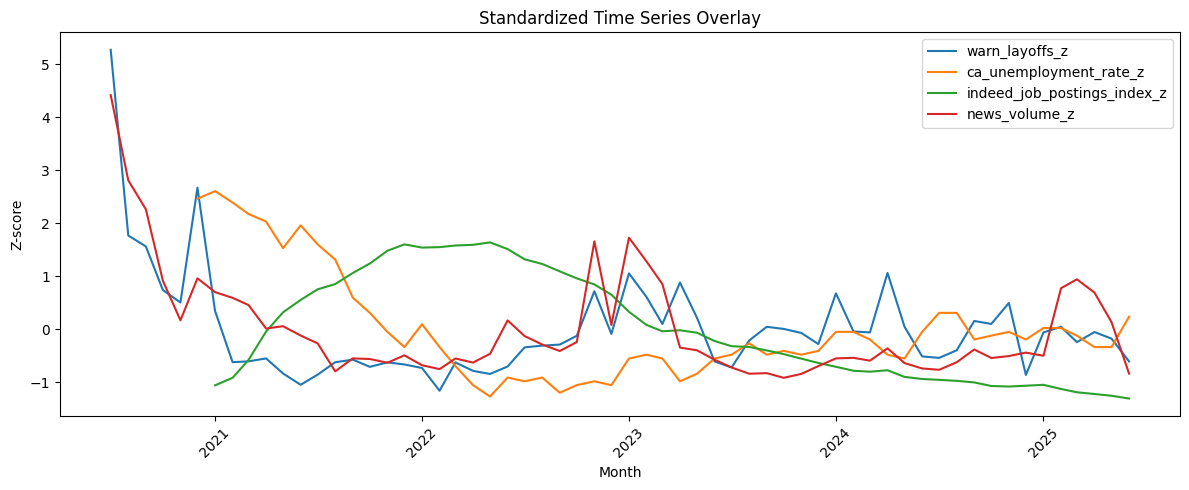

In [7]:
# Standardized overlay for lead-lag visual inspection
overlay_cols = [
    "warn_layoffs_z",
    "ca_unemployment_rate_z",
    "indeed_job_postings_index_z",
    "news_volume_z"
]

plt.figure(figsize=(12, 5))
for col in overlay_cols:
    plt.plot(master["month"], master[col], label=col)

plt.title("Standardized Time Series Overlay")
plt.xlabel("Month")
plt.ylabel("Z-score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/figures/02_standardized_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

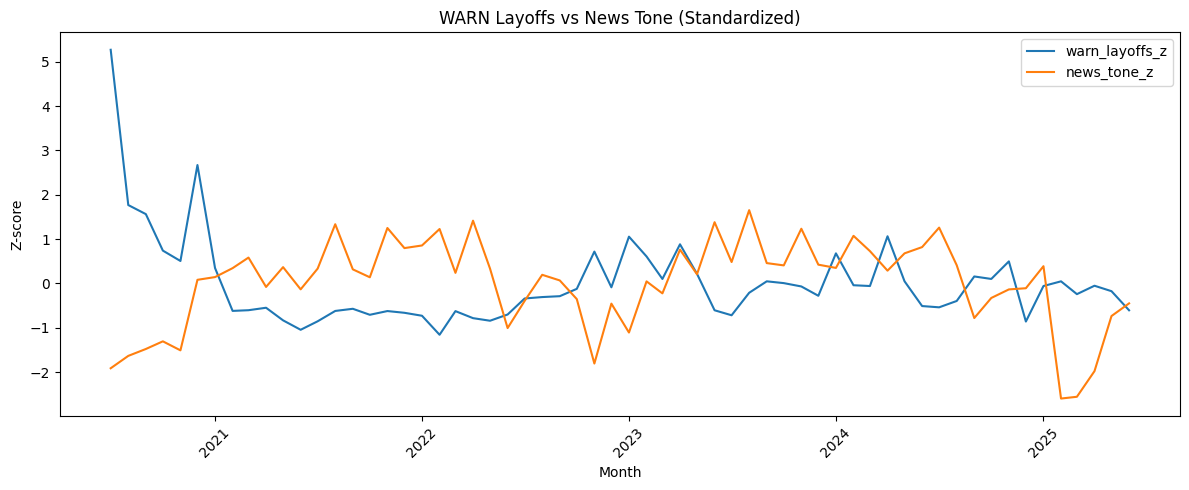

In [9]:
# WARN vs news tone
plt.figure(figsize=(12, 5))
plt.plot(master["month"], master["warn_layoffs_z"], label="warn_layoffs_z")
plt.plot(master["month"], master["news_tone_z"], label="news_tone_z")
plt.title("WARN Layoffs vs News Tone (Standardized)")
plt.xlabel("Month")
plt.ylabel("Z-score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/processed/figures/03_warn_vs_news_tone.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# Lead-lag correlation table: correlation of WARN at month t with predictor at t-lag

def build_lag_corr_table(df, target, predictors, max_lag=3):
    rows = []
    for predictor in predictors:
        for lag in range(0, max_lag + 1):
            corr = df[target].corr(df[predictor].shift(lag))
            rows.append({
                "predictor": predictor,
                "lag_months": lag,
                "correlation_with_warn": corr,
                "abs_correlation": abs(corr) if pd.notna(corr) else np.nan
            })
    return pd.DataFrame(rows)

predictors = [
    "ca_unemployment_rate",
    "fed_funds_rate",
    "indeed_job_postings_index",
    "news_volume",
    "news_tone"
]

lag_corr = build_lag_corr_table(master, "warn_layoffs", predictors, max_lag=3)
lag_corr

,predictor,lag_months,correlation_with_warn,abs_correlation
0,ca_unemployment_rate,0,-0.010570,0.010570
1,ca_unemployment_rate,1,-0.311022,0.311022
2,ca_unemployment_rate,2,-0.405223,0.405223
3,ca_unemployment_rate,3,-0.440316,0.440316
4,fed_funds_rate,0,0.586148,0.586148
5,fed_funds_rate,1,0.613040,0.613040
6,fed_funds_rate,2,0.586669,0.586669
7,fed_funds_rate,3,0.547743,0.547743
8,indeed_job_postings_index,0,-0.378918,0.378918
9,indeed_job_postings_index,1,-0.292506,0.292506


In [11]:
best_lags = (
    lag_corr.sort_values(["predictor", "abs_correlation"], ascending=[True, False])
    .groupby("predictor", as_index=False)
    .first()
    .sort_values("abs_correlation", ascending=False)
)

best_lags

,predictor,lag_months,correlation_with_warn,abs_correlation
4,news_volume,0,0.762144,0.762144
1,fed_funds_rate,1,0.613040,0.613040
3,news_tone,1,-0.462816,0.462816
0,ca_unemployment_rate,3,-0.440316,0.440316
2,indeed_job_postings_index,0,-0.378918,0.378918


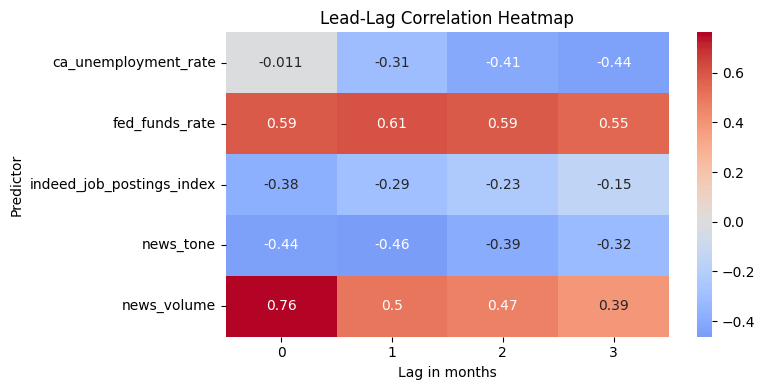

In [12]:
heatmap_data = lag_corr.pivot(index="predictor", columns="lag_months", values="correlation_with_warn")

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", center=0)
plt.title("Lead-Lag Correlation Heatmap")
plt.xlabel("Lag in months")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("../data/processed/figures/04_lag_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Regression: macro only vs macro + news
# Using lag1 predictors as a simple first-pass model

model_df = master.copy()

macro_features = [
    "ca_unemployment_rate_lag1",
    "fed_funds_rate_lag1",
    "indeed_job_postings_index_lag1"
]

full_features = macro_features + [
    "news_volume_log1p_lag1",
    "news_tone_lag1"
]

target = "warn_layoffs_log1p"

reg_df = model_df.dropna(subset=[target] + full_features).copy()

X1 = sm.add_constant(reg_df[macro_features])
X2 = sm.add_constant(reg_df[full_features])
y = reg_df[target]

model_macro = sm.OLS(y, X1).fit()
model_full = sm.OLS(y, X2).fit()

comparison = pd.DataFrame({
    "model": ["Macro only", "Macro + news"],
    "r_squared": [model_macro.rsquared, model_full.rsquared],
    "adj_r_squared": [model_macro.rsquared_adj, model_full.rsquared_adj],
    "aic": [model_macro.aic, model_full.aic],
    "bic": [model_macro.bic, model_full.bic]
})

comparison

,model,r_squared,adj_r_squared,aic,bic
0,Macro only,0.451982,0.418430,50.229469,58.110637
1,Macro + news,0.520824,0.469848,47.114729,58.936480


In [14]:
print(model_macro.summary())

                            OLS Regression Results                            
Dep. Variable:     warn_layoffs_log1p   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     13.47
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.55e-06
Time:                        12:39:09   Log-Likelihood:                -21.115
No. Observations:                  53   AIC:                             50.23
Df Residuals:                      49   BIC:                             58.11
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [15]:
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:     warn_layoffs_log1p   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     10.22
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.14e-06
Time:                        12:39:10   Log-Likelihood:                -17.557
No. Observations:                  53   AIC:                             47.11
Df Residuals:                      47   BIC:                             58.94
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [16]:
# Simple out-of-sample comparison using the last 12 months as test data

split_date = pd.Timestamp("2024-07-01")

def time_split_rmse(df, features, target, split_date):
    temp = df.dropna(subset=features + [target]).copy()
    
    train = temp[temp["month"] < split_date].copy()
    test = temp[temp["month"] >= split_date].copy()
    
    model = LinearRegression()
    model.fit(train[features], train[target])
    
    pred = model.predict(test[features])
    rmse = np.sqrt(mean_squared_error(test[target], pred))
    
    return rmse, len(train), len(test)

rmse_macro, n_train_macro, n_test_macro = time_split_rmse(reg_df, macro_features, target, split_date)
rmse_full, n_train_full, n_test_full = time_split_rmse(reg_df, full_features, target, split_date)

oos_compare = pd.DataFrame({
    "model": ["Macro only", "Macro + news"],
    "test_rmse": [rmse_macro, rmse_full],
    "train_rows": [n_train_macro, n_train_full],
    "test_rows": [n_test_macro, n_test_full]
})

oos_compare

,model,test_rmse,train_rows,test_rows
0,Macro only,0.372207,41,12
1,Macro + news,0.482842,41,12


In [17]:
# Risk classification feasibility
# Split WARN layoffs into 3 groups

master["risk_level"] = pd.qcut(
    master["warn_layoffs"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

risk_summary = (
    master.groupby("risk_level")[
        ["warn_layoffs", "ca_unemployment_rate", "indeed_job_postings_index", "news_volume", "news_tone"]
    ]
    .mean()
    .round(2)
)

risk_summary

/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_58236/3973494775.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master.groupby("risk_level")[


,warn_layoffs,ca_unemployment_rate,indeed_job_postings_index,news_volume,news_tone
risk_level,,,,,
Low,3185.85,5.91,131.53,14038.85,-1.51
Medium,5774.75,5.11,108.96,15242.80,-1.63
High,11521.15,5.35,107.49,24990.50,-1.74


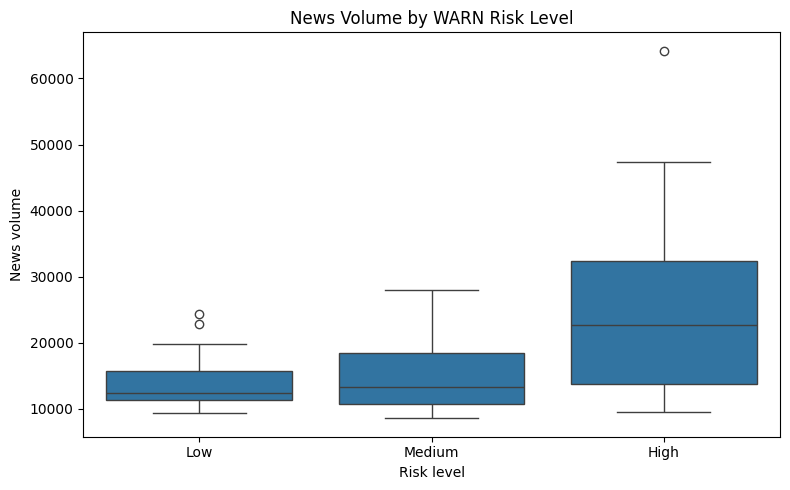

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=master, x="risk_level", y="news_volume")
plt.title("News Volume by WARN Risk Level")
plt.xlabel("Risk level")
plt.ylabel("News volume")
plt.tight_layout()
plt.savefig("../data/processed/figures/05_news_volume_by_risk_level.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
comparison.to_csv("../data/processed/model_comparison.csv", index=False)
oos_compare.to_csv("../data/processed/oos_comparison.csv", index=False)
best_lags.to_csv("../data/processed/best_lags.csv", index=False)
risk_summary.to_csv("../data/processed/risk_summary.csv")

These are just preliminary results. The models use a small monthly sample, so the findings should jsut be interpreted as directional evidence rather than final causal conclsions.